In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [3]:
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
block_size = 3

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] #sliding window

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [7]:
n_embd = 10 
n_hidden = 64 

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g)

W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 

W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1

bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1


parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

4137


In [8]:
#minibatch
batch_size = 32
n = batch_size
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

In [9]:
emb = C[Xb] 
embcat = emb.view(emb.shape[0], -1) 

hprebn = embcat @ W1 + b1 
# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias

h = torch.tanh(hpreact) # hidden layer

logits = h @ W2 + b2 # output layer

logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes 
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv,
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.3396, grad_fn=<NegBackward0>)

In [10]:
Yb #array of correct indices
-logprobs[range(n), Yb].mean() # pluck out corresponding correct indices from logprobs
#shape of this is 32x27, cause our batch size is 32

tensor(3.3396, grad_fn=<NegBackward0>)

In [11]:
#loss = -1/3a + -1/3b + -1/3c
#dloss/da = -1/n

In [12]:
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0/n
dprobs = (1.0 / probs) * dlogprobs
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
dcounts = counts_sum_inv * dprobs
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv
dcounts += torch.ones_like(counts) * dcounts_sum
dnorm_logits = counts * dcounts
dlogits = dnorm_logits.clone()
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes
dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)
dhpreact = (1.0 - h**2) * dh
dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
dbnraw = bngain * dhpreact
dbnbias = dhpreact.sum(0, keepdim=True)
dbndiff = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
dbndiff += (2*bndiff) * dbndiff2
dhprebn = dbndiff.clone()
dbnmeani = (-dbndiff).sum(0)
dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)
dembcat = dhprebn @ W1.T
dW1 = embcat.T @ dhprebn
db1 = dhprebn.sum(0)
demb = dembcat.view(emb.shape)
dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
  for j in range(Xb.shape[1]):
    ix = Xb[k,j]
    dC[ix] += demb[k,j]
    
cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff:

In [13]:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.339573621749878 diff: 0.0


In [14]:
dlogits = F.softmax(logits, 1)
dlogits[range(n), Yb] -= 1
dlogits /= n

cmp('logits', dlogits, logits)

logits          | exact: False | approximate: True  | maxdiff: 7.2177499532699585e-09


In [15]:
logits.shape, Yb.shape

(torch.Size([32, 27]), torch.Size([32]))

In [16]:
F.softmax(logits, 1)[0]

tensor([0.0724, 0.0920, 0.0185, 0.0475, 0.0198, 0.0813, 0.0231, 0.0364, 0.0188,
        0.0330, 0.0341, 0.0408, 0.0365, 0.0279, 0.0333, 0.0138, 0.0095, 0.0197,
        0.0161, 0.0541, 0.0482, 0.0208, 0.0257, 0.0714, 0.0597, 0.0258, 0.0198],
       grad_fn=<SelectBackward0>)

In [17]:
dlogits[0] * n

tensor([ 0.0724,  0.0920,  0.0185,  0.0475,  0.0198,  0.0813,  0.0231,  0.0364,
        -0.9812,  0.0330,  0.0341,  0.0408,  0.0365,  0.0279,  0.0333,  0.0138,
         0.0095,  0.0197,  0.0161,  0.0541,  0.0482,  0.0208,  0.0257,  0.0714,
         0.0597,  0.0258,  0.0198], grad_fn=<MulBackward0>)

In [18]:
dlogits[0].sum()

tensor(-9.3132e-10, grad_fn=<SumBackward0>)

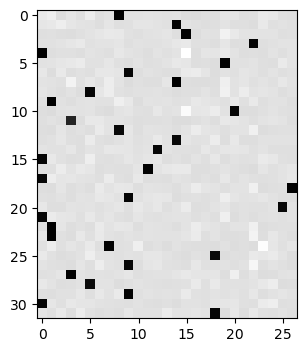

In [19]:
plt.figure(figsize=(4, 4))
plt.imshow(dlogits.detach(), cmap='gray')

In [20]:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(7.1526e-07, grad_fn=<MaxBackward1>)


In [21]:
dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))

cmp('hprebn', dhprebn, hprebn) # can only get approximate to be true, here maxdiff is 9e-10

hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


In [22]:
dhprebn.shape, bngain.shape, bnvar_inv.shape, dbnraw.shape, dbnraw.sum(0).shape

(torch.Size([32, 64]),
 torch.Size([1, 64]),
 torch.Size([1, 64]),
 torch.Size([32, 64]),
 torch.Size([64]))

In [23]:
n_embd = 10 
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g)

W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1

W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True


max_steps = 200000
batch_size = 32
n = batch_size
lossi = []


with torch.no_grad():


  for i in range(max_steps):

    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] 


    emb = C[Xb] 
    embcat = emb.view(emb.shape[0], -1) 
    
    hprebn = embcat @ W1 + b1 
    
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hprebn - bnmean) * bnvar_inv
    hpreact = bngain * bnraw + bnbias

    h = torch.tanh(hpreact) 
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Yb) 

    
    for p in parameters:
      p.grad = None
    

 
    dlogits = F.softmax(logits, 1)
    dlogits[range(n), Yb] -= 1
    dlogits /= n
    
    dh = dlogits @ W2.T
    dW2 = h.T @ dlogits
    db2 = dlogits.sum(0)
   
    dhpreact = (1.0 - h**2) * dh
    
    dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
    dbnbias = dhpreact.sum(0, keepdim=True)
    dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
    
    dembcat = dhprebn @ W1.T
    dW1 = embcat.T @ dhprebn
    db1 = dhprebn.sum(0)
    
    demb = dembcat.view(emb.shape)
    dC = torch.zeros_like(C)
    for k in range(Xb.shape[0]):
      for j in range(Xb.shape[1]):
        ix = Xb[k,j]
        dC[ix] += demb[k,j]
    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    
    lr = 0.1 if i < 100000 else 0.01 
    for p, grad in zip(parameters, grads):
      
      p.data += -lr * grad 

    
    if i % 10000 == 0:
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())


12297
      0/ 200000: 3.7844
  10000/ 200000: 2.1886
  20000/ 200000: 2.4367
  30000/ 200000: 2.5067
  40000/ 200000: 1.9840
  50000/ 200000: 2.4197
  60000/ 200000: 2.4108
  70000/ 200000: 2.0192
  80000/ 200000: 2.3207
  90000/ 200000: 2.1168
 100000/ 200000: 1.8959
 110000/ 200000: 2.3491
 120000/ 200000: 1.9357
 130000/ 200000: 2.4497
 140000/ 200000: 2.2122
 150000/ 200000: 2.2142
 160000/ 200000: 1.9571
 170000/ 200000: 1.8077
 180000/ 200000: 2.0362
 190000/ 200000: 1.9044


In [ ]:
# for p,g in zip(parameters, grads):
#   cmp(str(tuple(p.shape)), g, p)

In [24]:
with torch.no_grad():
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)

In [25]:
@torch.no_grad() 
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.071735143661499
val 2.1098716259002686


In [26]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size 
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)      
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # ------------
      # Sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carlah.
amorie.
khyim.
shreety.
sacarson.
mahnen.
den.
art.
kaqui.
ner.
kiah.
maiivon.
leigh.
ham.
join.
quint.
shoilea.
jadilyn.
jero.
dearynix.


## Extension

In [29]:
#gradient verification + vectorized embedding
#           backward + evaluation + temperature sampling


import math
import torch
import torch.nn.functional as F


# 1. Evaluation

@torch.no_grad()
def evaluate_split(X, Y, split_name):
    emb = C[X]
    embcat = emb.view(emb.shape[0], -1)

    hprebn = embcat @ W1 + b1
    hpreact = bngain * (
        (hprebn - bnmean) /
        torch.sqrt(bnvar + 1e-5)
    ) + bnbias

    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)

    perplexity = torch.exp(loss)

    print(
    f"{split_name:>5} | "
    f"loss: {loss.item():.4f} | "
    f"perplexity: {perplexity.item():.2f}"
    )

    return loss.item()


print("MODEL EVALUATION")
print("-" * 45)

train_loss = evaluate_split(Xtr, Ytr, "train")
val_loss   = evaluate_split(Xdev, Ydev, "val")
test_loss  = evaluate_split(Xte, Yte, "test")


# 2. Manual backward pass vs PyTorch autograd

@torch.no_grad()
def manual_backward(Xb, Yb):

    n = Xb.shape[0]


    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)

    hprebn = embcat @ W1 + b1

    bnmean_b = hprebn.mean(0, keepdim=True)
    bnvar_b = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar_b + 1e-5) ** -0.5
    bnraw = (hprebn - bnmean_b) * bnvar_inv
    hpreact = bngain * bnraw + bnbias

    h = torch.tanh(hpreact)
    logits = h @ W2 + b2

    # backward
    dlogits = F.softmax(logits, dim=1)
    dlogits[range(n), Yb] -= 1
    dlogits /= n

    dh = dlogits @ W2.T
    dW2 = h.T @ dlogits
    db2 = dlogits.sum(0)

    dhpreact = (1.0 - h**2) * dh

    dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
    dbnbias = dhpreact.sum(0, keepdim=True)

    dhprebn = (
        bngain * bnvar_inv / n
        * (
            n * dhpreact
            - dhpreact.sum(0)
            - n / (n - 1)
            * bnraw
            * (dhpreact * bnraw).sum(0)
        )
    )

    dembcat = dhprebn @ W1.T
    dW1 = embcat.T @ dhprebn
    db1 = dhprebn.sum(0)

    demb = dembcat.view(emb.shape)

    # Vectorized nested loops:
    #
    # for k in range(Xb.shape[0]):
    #     for j in range(Xb.shape[1]):
    #         ix = Xb[k, j]
    #         dC[ix] += demb[k, j]

    dC = torch.zeros_like(C)
    dC.index_add_(
        0,
        Xb.reshape(-1),
        demb.reshape(-1, n_embd)
    )

    return [dC, dW1, db1, dW2, db2, dbngain, dbnbias]


#fresh minibatch for verification
g_check = torch.Generator().manual_seed(12345)

ix = torch.randint(
    0,
    Xtr.shape[0],
    (batch_size,),
    generator=g_check
)

Xcheck = Xtr[ix]
Ycheck = Ytr[ix]


# Manual gradients
manual_grads = manual_backward(Xcheck, Ycheck)


# PyTorch autograd gradients
for p in parameters:
    p.grad = None

with torch.enable_grad():

    emb = C[Xcheck]
    embcat = emb.view(emb.shape[0], -1)

    hprebn = embcat @ W1 + b1

    bnmean_check = hprebn.mean(0, keepdim=True)
    bnvar_check = hprebn.var(
        0,
        keepdim=True,
        unbiased=True
    )

    hpreact = (
        bngain
        * (hprebn - bnmean_check)
        / torch.sqrt(bnvar_check + 1e-5)
        + bnbias
    )

    h = torch.tanh(hpreact)
    logits = h @ W2 + b2

    loss = F.cross_entropy(logits, Ycheck)
    loss.backward()

autograd_grads = [
    C.grad,
    W1.grad,
    b1.grad,
    W2.grad,
    b2.grad,
    bngain.grad,
    bnbias.grad
]


print("\nMANUAL BACKWARD vs AUTOGRAD")
print("-" * 60)

names = [
    "C",
    "W1",
    "b1",
    "W2",
    "b2",
    "bngain",
    "bnbias"
]

for name, manual, auto in zip(
    names,
    manual_grads,
    autograd_grads
):
    max_diff = (manual - auto).abs().max().item()
    close = torch.allclose(
        manual,
        auto,
        atol=1e-6,
        rtol=1e-5
    )

    print(
        f"{name:7s} | "
        f"max diff: {max_diff:.3e} | "
        f"match: {close}"
    )


# 3. Temperature-controlled sampling

@torch.no_grad()
def sample_names(num_samples=10, temperature=1.0):

    generated = []

    g_sample = torch.Generator().manual_seed(
        2147483647 + int(temperature * 1000)
    )

    for _ in range(num_samples):

        out = []
        context = [0] * block_size

        while True:

            emb = C[
                torch.tensor([context])
            ]

            embcat = emb.view(
                emb.shape[0],
                -1
            )

            hprebn = embcat @ W1 + b1

            hpreact = (
                bngain
                * (hprebn - bnmean)
                / torch.sqrt(bnvar + 1e-5)
                + bnbias
            )

            h = torch.tanh(hpreact)
            logits = h @ W2 + b2

            # Temperature changes the sharpness
            # of the probability distribution.
            probs = F.softmax(
                logits / temperature,
                dim=1
            )

            ix = torch.multinomial(
                probs,
                num_samples=1,
                generator=g_sample
            ).item()

            context = context[1:] + [ix]

            if ix == 0:
                break

            out.append(ix)

        generated.append(
            "".join(itos[i] for i in out)
        )

    return generated


print("\nTEMPERATURE SAMPLING")
print("-" * 60)

for temperature in [0.5, 0.8, 1.0, 1.2]:

    print(f"\nTemperature = {temperature}")

    names_generated = sample_names(
        num_samples=5,
        temperature=temperature
    )

    for name in names_generated:
        print(" ", name)


# 4. Parameter statistics

total_params = sum(
    p.nelement() for p in parameters
)

print("\nMODEL STATISTICS")
print("-" * 45)
print(f"parameters : {total_params:,}")
print(f"train loss : {train_loss:.4f}")
print(f"val loss   : {val_loss:.4f}")
print(f"test loss  : {test_loss:.4f}")

MODEL EVALUATION
---------------------------------------------
train | loss: 2.0717 | perplexity: 7.94
  val | loss: 2.1099 | perplexity: 8.25
 test | loss: 2.1107 | perplexity: 8.25

MANUAL BACKWARD vs AUTOGRAD
------------------------------------------------------------
C       | max diff: 2.887e-08 | match: True
W1      | max diff: 1.304e-08 | match: True
b1      | max diff: 7.451e-09 | match: True
W2      | max diff: 1.863e-08 | match: True
b2      | max diff: 9.313e-09 | match: True
bngain  | max diff: 5.588e-09 | match: True
bnbias  | max diff: 1.118e-08 | match: True

TEMPERATURE SAMPLING
------------------------------------------------------------

Temperature = 0.5
  sader
  maleya
  aubriel
  wilden
  kola

Temperature = 0.8
  pran
  adalessia
  gere
  armo
  ahad

Temperature = 1.0
  nie
  rumath
  abrianah
  anaiel
  elin

Temperature = 1.2
  pethindleeaganellynnslina
  phi
  orilyahja
  jezithko
  vina

MODEL STATISTICS
---------------------------------------------
paramet

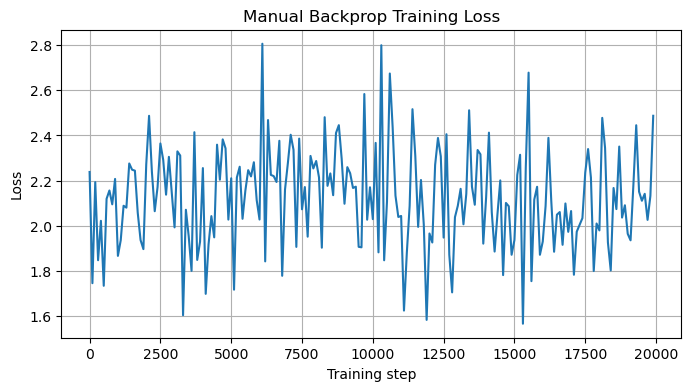

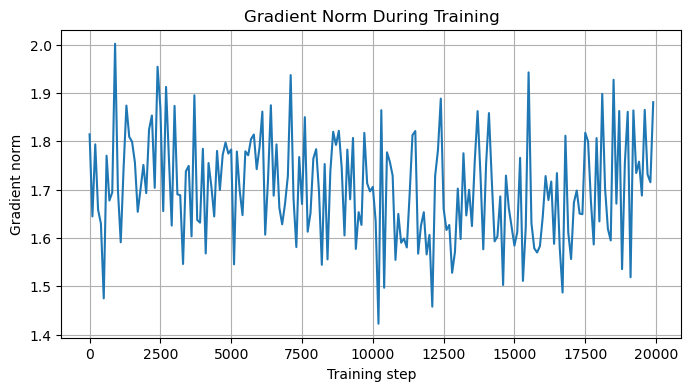

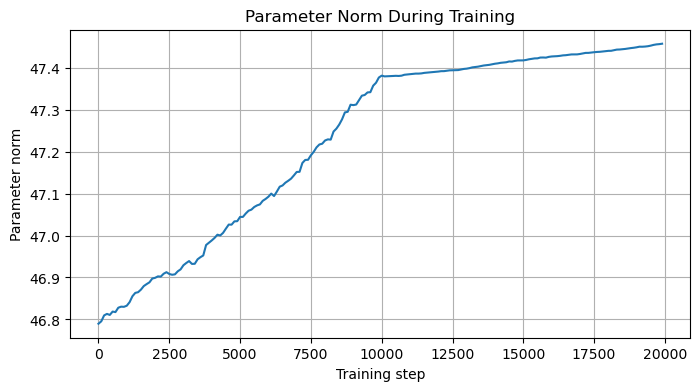

TRAINING DYNAMICS
--------------------------------------------------
initial loss       : 2.2383
final loss         : 2.4869
initial grad norm  : 1.8142
final grad norm    : 1.8807
initial param norm : 46.7898
final param norm   : 47.4571


In [30]:
#training dynamics and gradient analysis


import matplotlib.pyplot as plt




trace_steps = []
trace_loss = []
trace_grad_norm = []
trace_param_norm = []


def get_grad_norm(grads):
    return torch.sqrt(
        sum((g.detach() ** 2).sum() for g in grads)
    ).item()


def get_param_norm(parameters):
    return torch.sqrt(
        sum((p.detach() ** 2).sum() for p in parameters)
    ).item()


analysis_parameters = [
    p.detach().clone()
    for p in parameters
]

C_a, W1_a, b1_a, W2_a, b2_a, bngain_a, bnbias_a = analysis_parameters


analysis_steps = 20000
analysis_batch_size = 32
analysis_g = torch.Generator().manual_seed(42)

with torch.no_grad():

    for i in range(analysis_steps):

        ix = torch.randint(
            0,
            Xtr.shape[0],
            (analysis_batch_size,),
            generator=analysis_g
        )

        Xb, Yb = Xtr[ix], Ytr[ix]
        n = analysis_batch_size



        emb = C_a[Xb]
        embcat = emb.view(emb.shape[0], -1)

        hprebn = embcat @ W1_a + b1_a

        bnmean = hprebn.mean(0, keepdim=True)
        bnvar = hprebn.var(
            0,
            keepdim=True,
            unbiased=True
        )

        bnvar_inv = (bnvar + 1e-5) ** -0.5
        bnraw = (hprebn - bnmean) * bnvar_inv

        hpreact = bngain_a * bnraw + bnbias_a

        h = torch.tanh(hpreact)

        logits = h @ W2_a + b2_a

        loss = F.cross_entropy(logits, Yb)


        dlogits = F.softmax(logits, dim=1)
        dlogits[range(n), Yb] -= 1
        dlogits /= n

        dh = dlogits @ W2_a.T

        dW2 = h.T @ dlogits
        db2 = dlogits.sum(0)

        dhpreact = (1.0 - h**2) * dh

        dbngain = (
            bnraw * dhpreact
        ).sum(0, keepdim=True)

        dbnbias = dhpreact.sum(
            0,
            keepdim=True
        )

        dhprebn = (
            bngain_a * bnvar_inv / n
            * (
                n * dhpreact
                - dhpreact.sum(0)
                - n / (n - 1)
                * bnraw
                * (
                    dhpreact * bnraw
                ).sum(0)
            )
        )

        dembcat = dhprebn @ W1_a.T

        dW1 = embcat.T @ dhprebn
        db1 = dhprebn.sum(0)

        demb = dembcat.view(emb.shape)

        dC = torch.zeros_like(C_a)

        dC.index_add_(
            0,
            Xb.reshape(-1),
            demb.reshape(-1, n_embd)
        )

        grads = [
            dC,
            dW1,
            db1,
            dW2,
            db2,
            dbngain,
            dbnbias
        ]



        if i % 100 == 0:

            trace_steps.append(i)
            trace_loss.append(loss.item())
            trace_grad_norm.append(
                get_grad_norm(grads)
            )
            trace_param_norm.append(
                get_param_norm(analysis_parameters)
            )


        lr = 0.1 if i < 10000 else 0.01

        for p, grad in zip(
            analysis_parameters,
            grads
        ):
            p -= lr * grad



plt.figure(figsize=(8, 4))
plt.plot(trace_steps, trace_loss)
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Manual Backprop Training Loss")
plt.grid(True)
plt.show()




plt.figure(figsize=(8, 4))
plt.plot(trace_steps, trace_grad_norm)
plt.xlabel("Training step")
plt.ylabel("Gradient norm")
plt.title("Gradient Norm During Training")
plt.grid(True)
plt.show()




plt.figure(figsize=(8, 4))
plt.plot(trace_steps, trace_param_norm)
plt.xlabel("Training step")
plt.ylabel("Parameter norm")
plt.title("Parameter Norm During Training")
plt.grid(True)
plt.show()



print("TRAINING DYNAMICS")
print("-" * 50)
print(f"initial loss       : {trace_loss[0]:.4f}")
print(f"final loss         : {trace_loss[-1]:.4f}")
print(f"initial grad norm  : {trace_grad_norm[0]:.4f}")
print(f"final grad norm    : {trace_grad_norm[-1]:.4f}")
print(f"initial param norm : {trace_param_norm[0]:.4f}")
print(f"final param norm   : {trace_param_norm[-1]:.4f}")